# 1. Budowa zbioru danych z plików IFC

Tu buduję właściwy dataset. Biorę surowe pliki z
`data/raw/IFCNetCoreIFC/{IfcBeam,IfcSlab,IfcStair,IfcWall}/{train,test}/*.ifc`,
z każdego wczytuję geometrię pojedynczego elementu i liczę nowe cechy
geometryczne / inżynierskie (`src/feature_engineering.py`) — czyli to samo,
co rozpisywałem krok po kroku w `00_feature_engineering.ipynb`, tylko teraz
w pętli po wszystkich plikach.

- surowe dane: `data/raw/IFCNetCoreIFC/`
- wynik (dataset po feature engineeringu): `data/processed/ifc_features.csv`

In [1]:
import sys
from pathlib import Path

import ifcopenshell
import pandas as pd
from tqdm.auto import tqdm

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from feature_engineering import extract_features
from ifc_geometry import get_single_element, load_mesh

DATA_DIR = ROOT / "data" / "raw" / "IFCNetCoreIFC"
OUT_CSV = ROOT / "data" / "processed" / "ifc_features.csv"
ERROR_LOG = ROOT / "reports" / "extraction_errors.log"

TARGET_CLASSES = ["IfcBeam", "IfcSlab", "IfcStair", "IfcWall"]
SPLITS = ["train", "test"]

In [2]:
def iter_files():
    for cls in TARGET_CLASSES:
        for split in SPLITS:
            folder = DATA_DIR / cls / split
            for path in sorted(folder.glob("*.ifc")):
                yield cls, split, path


def build_row(cls: str, split: str, path: Path) -> dict:
    ifc_file = ifcopenshell.open(str(path))
    element = get_single_element(ifc_file)
    mesh = load_mesh(element)
    feats = extract_features(mesh)
    row = {
        "file": path.name,
        "split": split,
        "label": cls.replace("Ifc", ""),      # ground-truth class (folder)
        "stored_ifc_class": element.is_a(),   # entity type actually written in the file
        "type_mismatch": element.is_a() != cls,
        "guid": element.GlobalId,
        "name": element.Name or "",
    }
    row.update(feats)
    return row

In [3]:
files = list(iter_files())
rows = []
errors = []

for cls, split, path in tqdm(files, desc="extracting features"):
    try:
        rows.append(build_row(cls, split, path))
    except Exception as exc:  # noqa: BLE001
        errors.append(f"{cls}/{split}/{path.name}: {exc!r}")

len(rows), len(errors)

extracting features:   0%|          | 0/1378 [00:00<?, ?it/s]

(1378, 0)

In [4]:
OUT_CSV.parent.mkdir(exist_ok=True)
ERROR_LOG.parent.mkdir(exist_ok=True)

df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)

with open(ERROR_LOG, "w", encoding="utf-8") as f:
    f.write("\n".join(errors))

print(f"wrote {len(df)} rows -> {OUT_CSV}")
print(f"failed on {len(errors)} files -> {ERROR_LOG}")
df["label"].value_counts()

wrote 1378 rows -> C:\Users\agata\OneDrive\Desktop\Test\ifc_test\data\processed\ifc_features.csv
failed on 0 files -> C:\Users\agata\OneDrive\Desktop\Test\ifc_test\reports\extraction_errors.log


label
Wall     537
Slab     507
Beam     282
Stair     52
Name: count, dtype: int64

In [5]:
print(f"type_mismatch (stored class != folder label): {int(df['type_mismatch'].sum())} rows")
df.head()

type_mismatch (stored class != folder label): 217 rows


,file,split,label,stored_ifc_class,type_mismatch,guid,name,n_vertices,n_faces,surface_area_m2,...,horizontal_aspect_ratio,footprint_area_m2,verticality_ratio,thickness_to_span_ratio,max_axis_verticality,incline_angle_deg,footprint_perimeter_m,footprint_compactness,cross_section_area_cv,step_count_proxy
0,001b165474224004852eb66107868b63.ifc,train,Beam,IfcBeam,False,1LrB8q00Fi434qD30mC3Co,KNPL 320,302,616,40.718696,...,7.664741,7.579022,0.040836,0.043198,0.999825,6.804576e-04,17.193320,0.322184,9.697838e-01,4
1,00bfb1c0b7af46d98c47b38044db237a.ifc,train,Beam,IfcBeam,False,3TdUePqxX7L8RNy$00k37G,ANGLE,57,110,4.151005,...,66.107540,1.063045,0.014698,0.011633,0.710600,2.893070e-02,17.258720,0.044848,5.336094e-04,4
2,02431d448db249f2ac8eb7ac5115cf14.ifc,train,Beam,IfcBeam,False,1LwOoJ003aEp4qD34pDZap,VWA,96,192,1.611900,...,10.164660,0.260215,0.098380,0.098380,1.000000,1.256777e-14,3.572691,0.256184,1.124860e-14,18
3,037f778074de491aa8d0199ae265ebbd.ifc,train,Beam,IfcBeam,False,1Ve4u0BH9EMPxUuX9TrDYM,STRINGER,108,212,1.162097,...,9.400736,0.106640,0.342818,0.115427,0.998547,2.396815e+00,2.361038,0.240395,8.272779e-01,5
4,03900d0c5178435d877505185bf01b69.ifc,train,Beam,IfcBeam,False,2rym_kGRn10w5rBFpFavij,BEAM,145,286,0.621017,...,1.883908,0.116905,0.524787,0.490568,0.958865,1.646872e+01,1.460484,0.688731,2.501074e+00,5


## EDA

Szybka eksploracja `data/processed/ifc_features.csv`, czyli danych już po
feature engineeringu: balans klas, braki danych, rozkłady cech per klasa,
korelacje między cechami.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
REPORTS_DIR = ROOT / "reports"
EDA_DIR = REPORTS_DIR / "eda"
EDA_DIR.mkdir(parents=True, exist_ok=True)

NON_FEATURE_COLS = ["file", "split", "label", "stored_ifc_class", "type_mismatch", "guid", "name"]
feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS]

print("Braki danych (NaN) per kolumna:")
missing = df.isna().sum()
missing = missing[missing > 0]
print(missing if len(missing) else "brak brakow danych")

Braki danych (NaN) per kolumna:
brak brakow danych


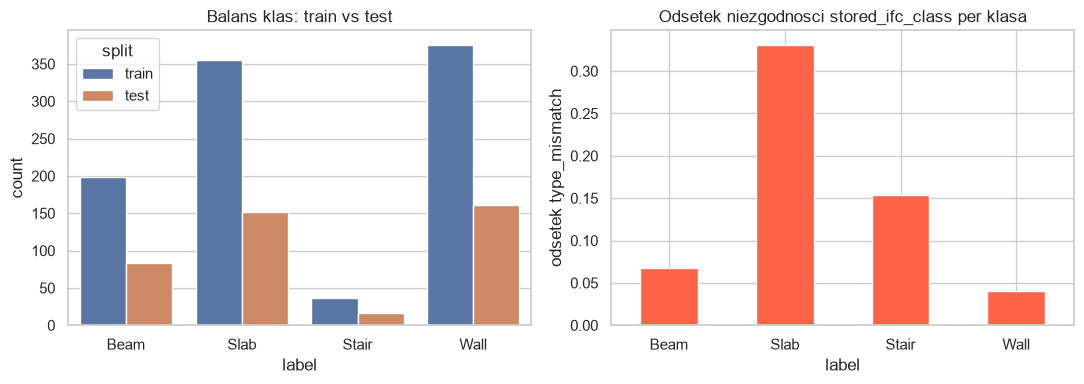

In [7]:
labels_order = sorted(df["label"].unique())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=df, x="label", hue="split", order=labels_order, ax=axes[0])
axes[0].set_title("Balans klas: train vs test")

mismatch_rate = df.groupby("label")["type_mismatch"].mean().reindex(labels_order)
mismatch_rate.plot(kind="bar", ax=axes[1], color="tomato", rot=0)
axes[1].set_ylabel("odsetek type_mismatch")
axes[1].set_title("Odsetek niezgodnosci stored_ifc_class per klasa")
fig.tight_layout()
fig.savefig(EDA_DIR / "class_balance.png", dpi=150)
plt.show()

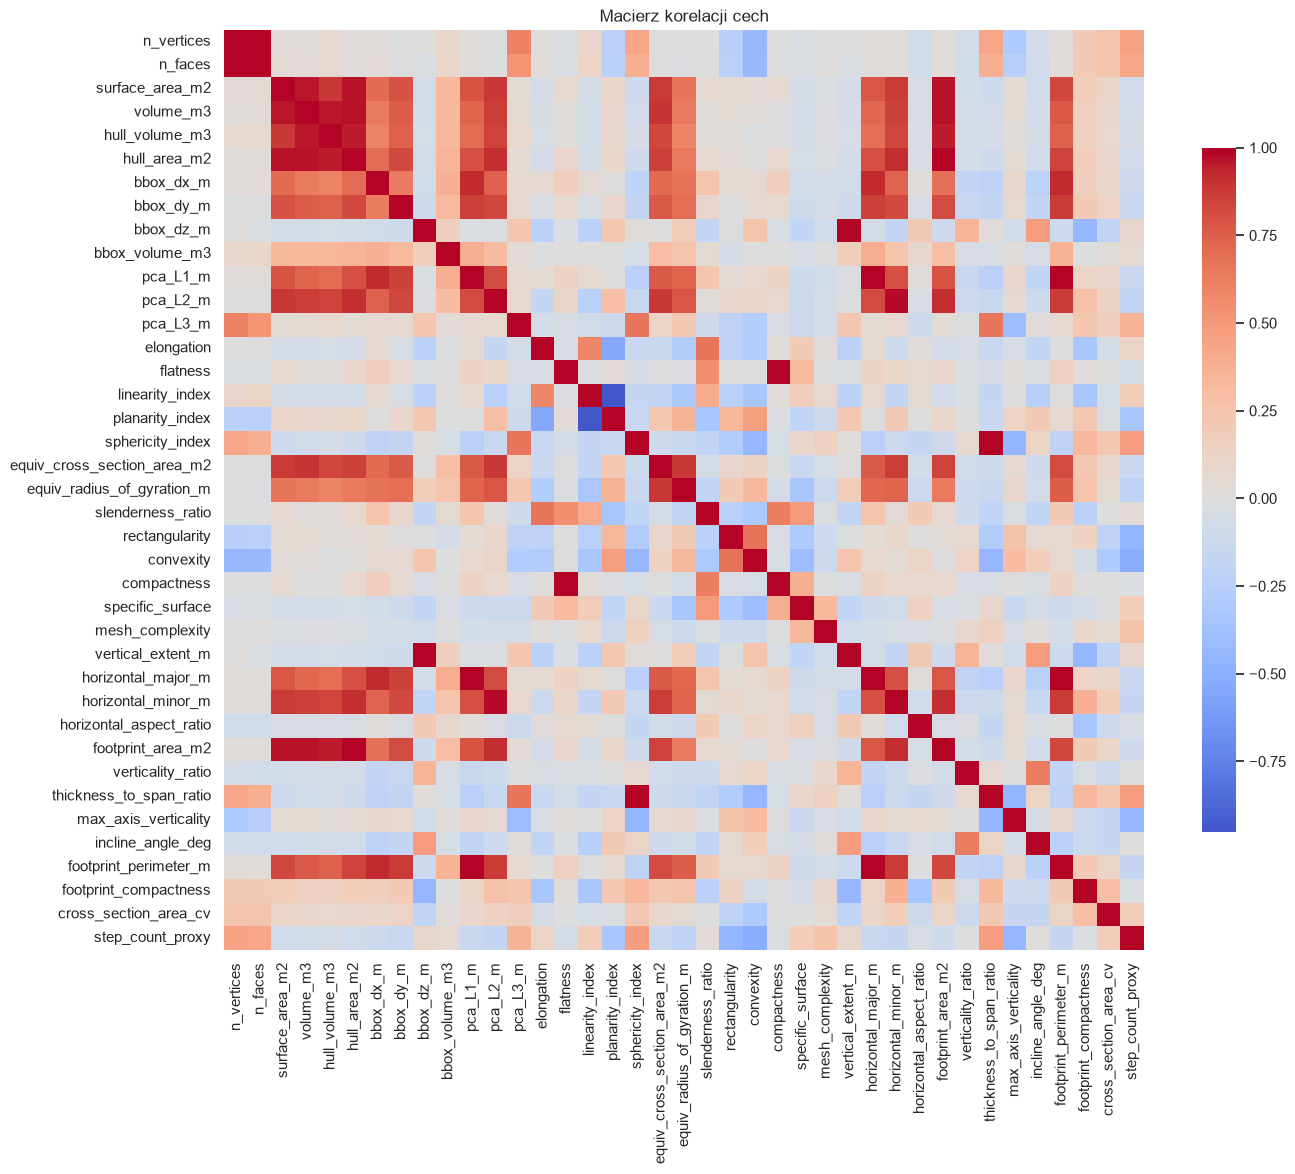

bbox_dz_m                vertical_extent_m          1.000000
vertical_extent_m        bbox_dz_m                  1.000000
thickness_to_span_ratio  sphericity_index           1.000000
sphericity_index         thickness_to_span_ratio    1.000000
horizontal_major_m       pca_L1_m                   0.997893
pca_L1_m                 horizontal_major_m         0.997893
footprint_area_m2        hull_area_m2               0.997150
hull_area_m2             footprint_area_m2          0.997150
compactness              flatness                   0.990426
flatness                 compactness                0.990426
dtype: float64

In [8]:
import numpy as np

corr = df[feature_cols].corr()
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, ax=ax,
            cbar_kws={"shrink": 0.7}, xticklabels=True, yticklabels=True)
ax.set_title("Macierz korelacji cech")
fig.tight_layout()
fig.savefig(EDA_DIR / "feature_correlations.png", dpi=150)
plt.show()

# najsilniej skorelowane pary cech (poza przekatna)
mask = ~np.eye(len(corr), dtype=bool)
pairs = corr.where(mask).unstack().dropna().sort_values(key=lambda s: s.abs(), ascending=False)
pairs = pairs[~pairs.index.duplicated()]
pairs.head(10)

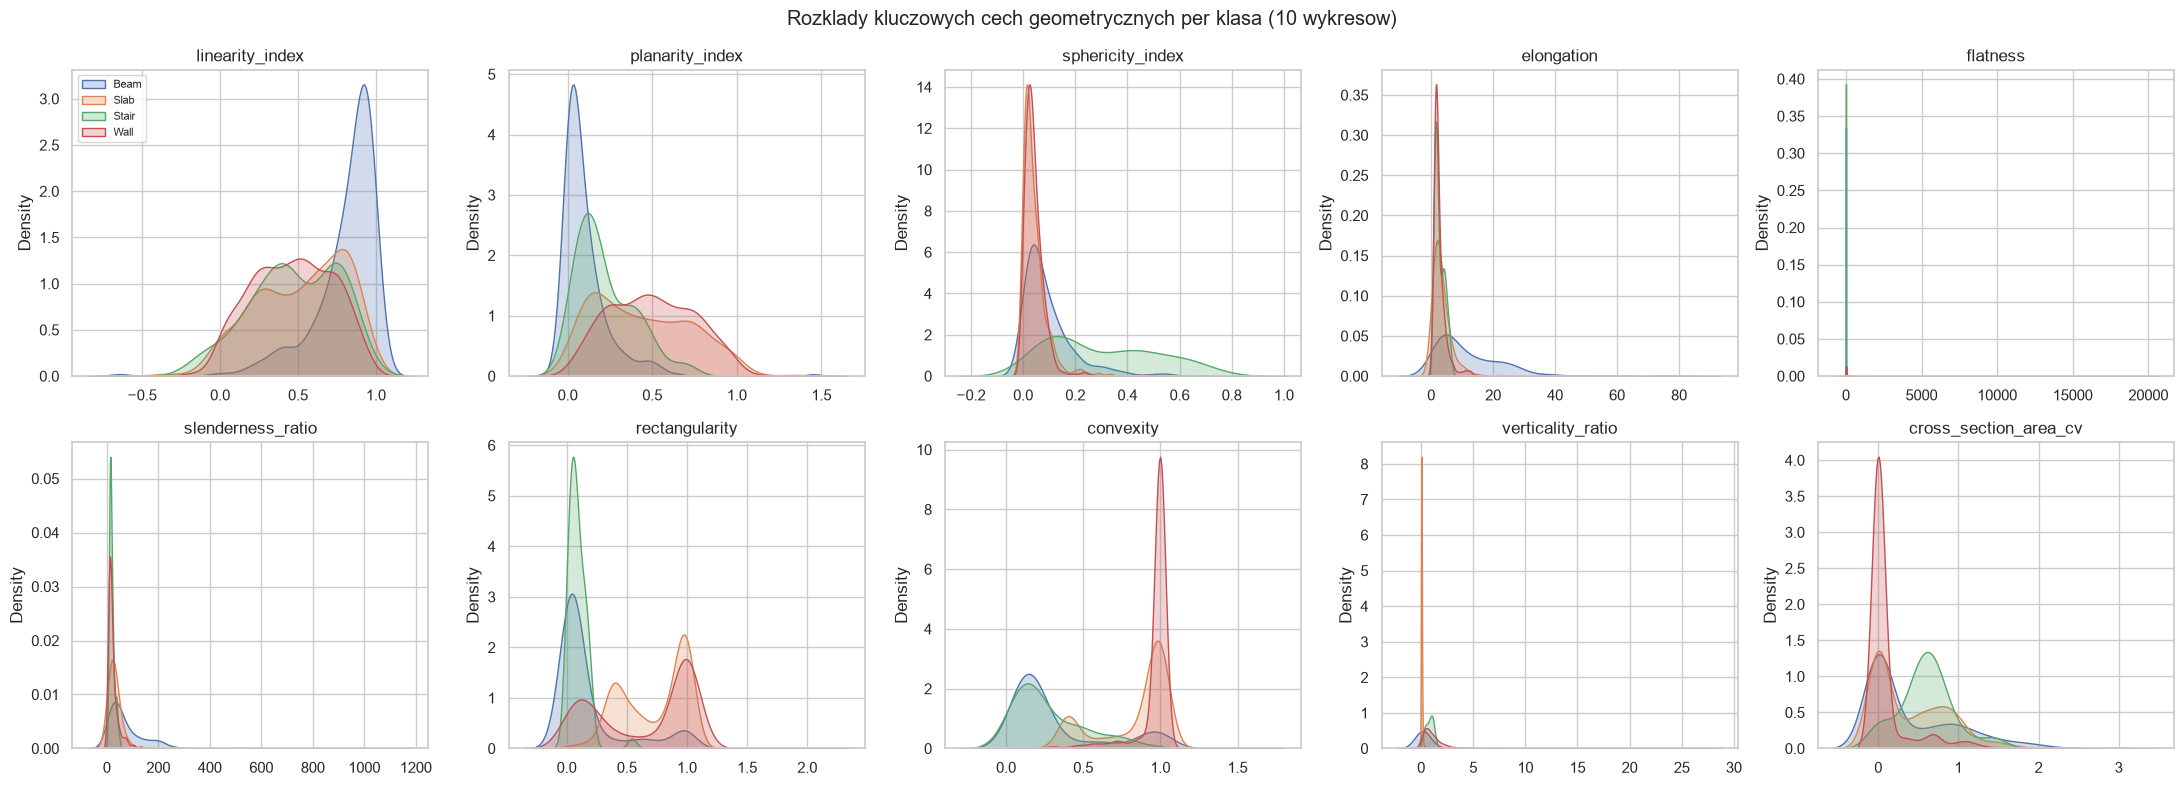

In [9]:
key_features = [
    "linearity_index", "planarity_index", "sphericity_index", "elongation", "flatness",
    "slenderness_ratio", "rectangularity", "convexity", "verticality_ratio",
    "cross_section_area_cv",
]

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
for ax, feat in zip(axes.ravel(), key_features):
    for label in labels_order:
        sns.kdeplot(df.loc[df["label"] == label, feat], ax=ax, label=label, fill=True, alpha=0.25, warn_singular=False)
    ax.set_title(feat)
    ax.set_xlabel("")
axes[0, 0].legend(fontsize=8)
fig.suptitle("Rozklady kluczowych cech geometrycznych per klasa (10 wykresow)")
fig.tight_layout()
fig.savefig(EDA_DIR / "feature_distributions.png", dpi=150)
plt.show()

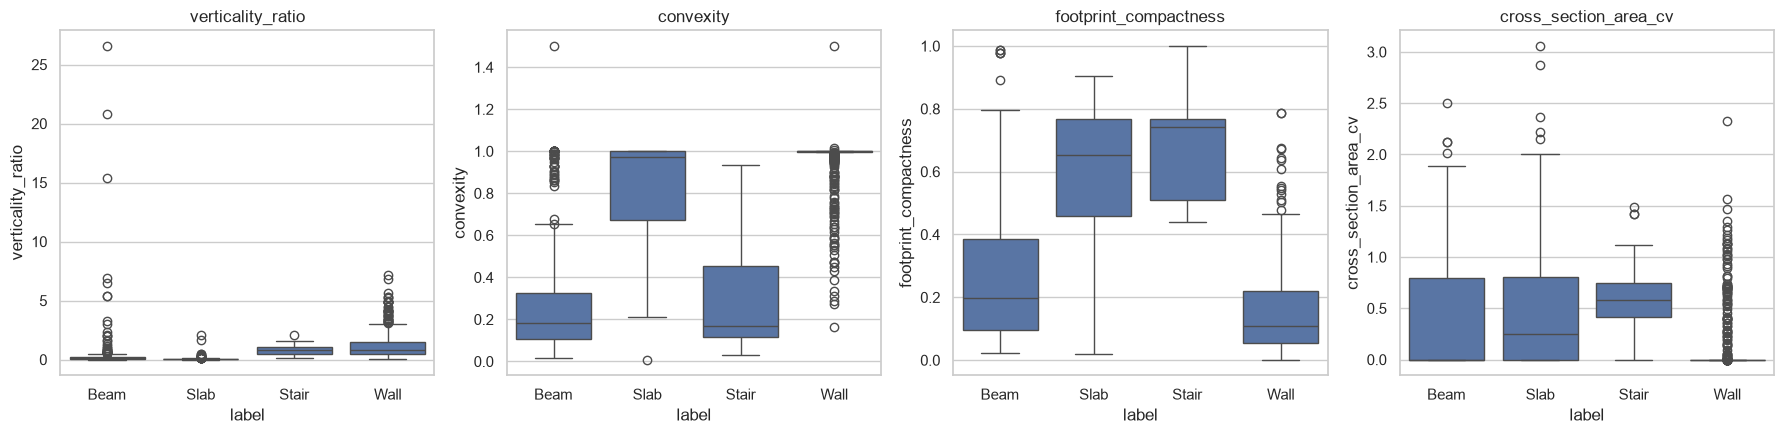

In [10]:
box_features = ["verticality_ratio", "convexity", "footprint_compactness", "cross_section_area_cv"]
fig, axes = plt.subplots(1, len(box_features), figsize=(18, 4.5))
for ax, feat in zip(axes, box_features):
    sns.boxplot(data=df, x="label", y=feat, order=labels_order, ax=ax)
    ax.set_title(feat)
fig.tight_layout()
fig.savefig(EDA_DIR / "feature_boxplots.png", dpi=150)
plt.show()

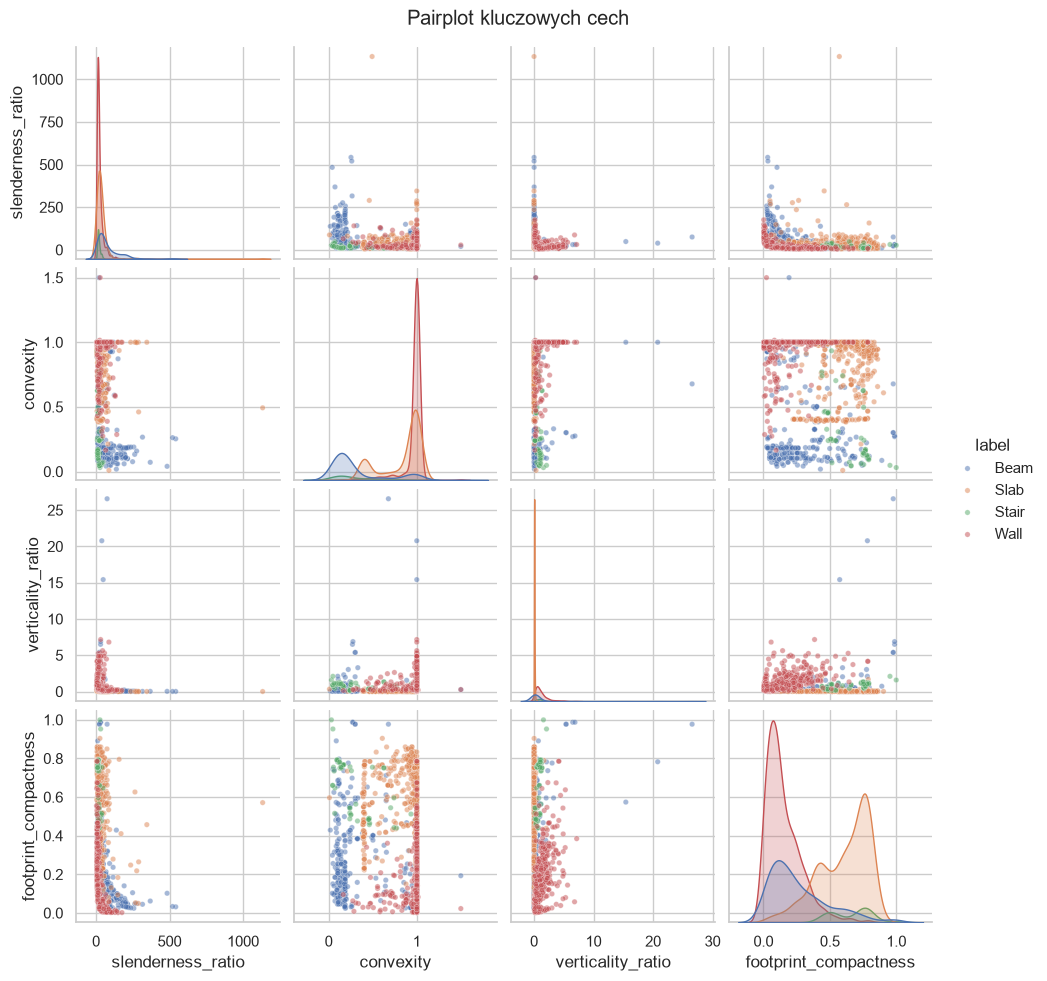

In [11]:
pairplot_features = ["slenderness_ratio", "convexity", "verticality_ratio", "footprint_compactness"]
g = sns.pairplot(df, vars=pairplot_features, hue="label", hue_order=labels_order,
                  plot_kws={"alpha": 0.5, "s": 15}, diag_kind="kde", height=2.4)
g.fig.suptitle("Pairplot kluczowych cech", y=1.02)
g.savefig(EDA_DIR / "feature_pairplot.png", dpi=150)
plt.show()